# Capstone project - Air passengers, start to finish

The course pipeline, on this series: explore it, decompose it, set the
benchmark floor, check what the floor leaves on the table, fit a model
through the framework, cross-validate, and read the result against the
floor.

**What is graded is the process, not the number.** A low MASE from one
holdout with no intervals scores worse than an honest analysis that
concludes the benchmark wins.

Full rules and report requirements: `brief.md`. Grading: `rubric.md`. This
notebook is the first deliverable; it should run top to bottom in under ten
minutes on Colab.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/SDAIAAcademy/international-airpassengers-project.git /content/proj
    %cd /content/proj
    !pip install -q -e .

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coursekit import plotting as P
from coursekit import scoring

P.use_course_style()

SEASON_LENGTH = 12
H = 12            # forecast horizon for cross-validation
H_REPORT = 24     # forecast horizon for the report

/content/proj
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.7 MB/s eta 0:00:00
  Building editable for international-airpassengers-project (pyproject.toml) ... done


/content/proj/coursekit/plotting.py:599: SyntaxWarning: invalid escape sequence '\h'
  :math:`\hat{F}` whose characteristics do not change over time -- so that a
/content/proj/coursekit/plotting.py:676: SyntaxWarning: invalid escape sequence '\h'
  """Draw the h-step errors :math:`e_{t+h|t} = y_{t+h} - \hat{y}_{t+h|t}`.


---
# 0. The data

Monthly international air passenger numbers, 1949-01 to 1960-12: 144
observations, no gaps. The Box & Jenkins classic (1970) — twelve years of
growth, and a year that does not repeat the same way twice.

Fetched from statsmodels' R-datasets on first run; no download step.

In [2]:
from statsmodels.datasets import get_rdataset

raw = get_rdataset("AirPassengers").data
t = raw["time"].astype(float).to_numpy()
years = np.floor(t).astype(int)
months = np.clip(np.round((t - years) * 12).astype(int) + 1, 1, 12)
df = pd.DataFrame({
    "unique_id": "Air passengers (Box & Jenkins)",
    "ds": pd.to_datetime(pd.Series(years).astype(str) + "-" +
                         pd.Series(months).astype(str).str.zfill(2) + "-01"),
    "y": raw["value"].astype(float),
}).sort_values("ds").reset_index(drop=True)
df.head()

,unique_id,ds,y
0,Air passengers (Box & Jenkins),1949-01-01,112.0
1,Air passengers (Box & Jenkins),1949-02-01,118.0
2,Air passengers (Box & Jenkins),1949-03-01,132.0
3,Air passengers (Box & Jenkins),1949-04-01,129.0
4,Air passengers (Box & Jenkins),1949-05-01,121.0


In [11]:
n_obs = len(df)

range_ = (
    df["ds"].min(),
    df["ds"].max()
)

expected_dates = pd.date_range(
    start=df["ds"].min(),
    end=df["ds"].max(),
    freq="MS"
)

n_gaps = len(expected_dates.difference(df["ds"]))

print(
    f"{n_obs} months, "
    f"{range_[0].date()} to {range_[1].date()}, "
    f"{n_gaps} gaps"
)

144 months, 1949-01-01 to 1960-12-01, 0 gaps


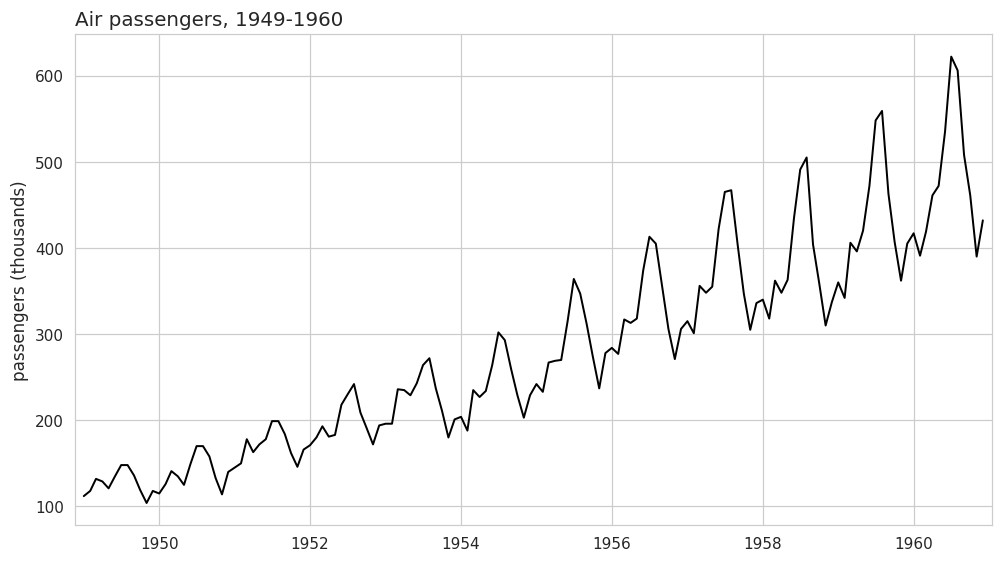

In [4]:
P.plot_series(df, title="Air passengers, 1949-1960",
              ylabel="passengers (thousands)", xlabel="")
plt.show()

The series shows a strong upward trend in international air passengers from 1949 to 1960. It also has clear yearly seasonality, with larger seasonal fluctuations as the overall passenger level increases.

---
# 1. Exploration and shape

The Day 1 toolkit, in order. Every chart should carry its claim: a title that
says what it shows, not just "series".

**1.1 Decompose.** STL, additive, period 12. Read all three panels: which
component does the work, and what does the remainder look like?

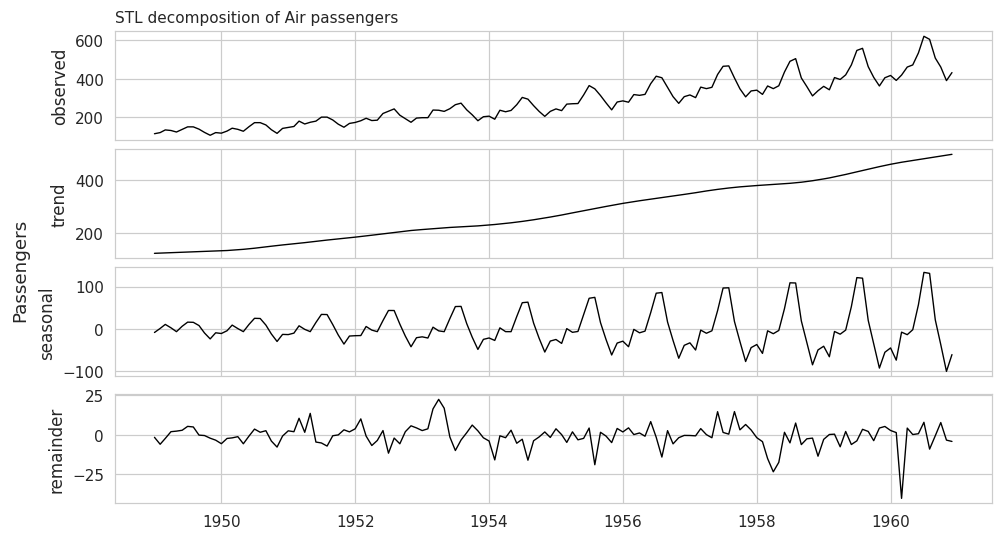

In [12]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    df["y"],
    period=12,
    seasonal=13,
    robust=True
)

result = stl.fit()

dcmp = pd.DataFrame({
    "ds": df["ds"],
    "observed": df["y"],
    "trend": result.trend,
    "seasonal": result.seasonal,
    "remainder": result.resid
})

P.decomposition_plot(
    dcmp,
    cols=["observed", "trend", "seasonal", "remainder"],
    title="STL decomposition of Air passengers",
    ylabel="Passengers",
    x="ds"
)

plt.show()

The trend component explains most of the long-term movement in the series, while the seasonal component shows a strong repeating yearly pattern. The remainder is relatively smaller but still contains some structure, suggesting that a model should capture both trend and seasonality.

**1.2 Trend and seasonal strength.** The two numbers from Day 1, computed
the same way (textbook formulas on the STL components). State what they
imply for model choice.

In [13]:
trend = result.trend
seasonal = result.seasonal
remainder = result.resid

trend_strength = max(
    0,
    1 - np.var(remainder) / np.var(trend + remainder)
)

seasonal_strength = max(
    0,
    1 - np.var(remainder) / np.var(seasonal + remainder)
)

print(f"trend strength: {trend_strength:.2f}")
print(f"seasonal strength: {seasonal_strength:.2f}")

trend strength: 1.00
seasonal strength: 0.97


Both trend and seasonal strength are high, confirming that the series contains strong non-random structure. Therefore, the forecasting model should explicitly handle both trend and yearly seasonality.

**1.3 Autocorrelation.** The ACF of the raw series. What is at lag 12?
At 24? What does that tell you before you fit anything?

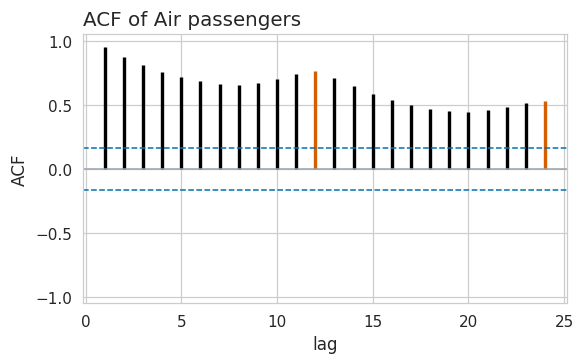

In [14]:
P.acf_plot(
    df["y"],
    nlags=24,
    title="ACF of Air passengers",
    highlight_every=12
)

plt.show()

The ACF remains strongly positive across many lags, showing strong persistence. The large spike around lag 12 confirms yearly seasonality, while the pattern around lag 24 shows that the seasonal dependence repeats at two-year spacing.

---
# 2. The floor

The seasonal naive is the first model you fit on any series - not as a
formality, as the thing everything else has to beat. Fit it, check what it
leaves on the table, and give it an honest interval.

In [15]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

floor_sf = StatsForecast(models=[SeasonalNaive(season_length=SEASON_LENGTH)],
                         freq="MS", n_jobs=1)
floor_fc = floor_sf.forecast(df=df, h=H_REPORT, level=scoring.LEVELS)
floor_fc.head()

,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1961-01-01,417.0,407.799511,397.956005,386.435898,370.4595,345.822448,426.200489,436.043995,447.564102,463.5405,488.177552
1,Air passengers (Box & Jenkins),1961-02-01,391.0,381.799511,371.956005,360.435898,344.4595,319.822448,400.200489,410.043995,421.564102,437.5405,462.177552
2,Air passengers (Box & Jenkins),1961-03-01,419.0,409.799511,399.956005,388.435898,372.4595,347.822448,428.200489,438.043995,449.564102,465.5405,490.177552
3,Air passengers (Box & Jenkins),1961-04-01,461.0,451.799511,441.956005,430.435898,414.4595,389.822448,470.200489,480.043995,491.564102,507.5405,532.177552
4,Air passengers (Box & Jenkins),1961-05-01,472.0,462.799511,452.956005,441.435898,425.4595,400.822448,481.200489,491.043995,502.564102,518.5405,543.177552


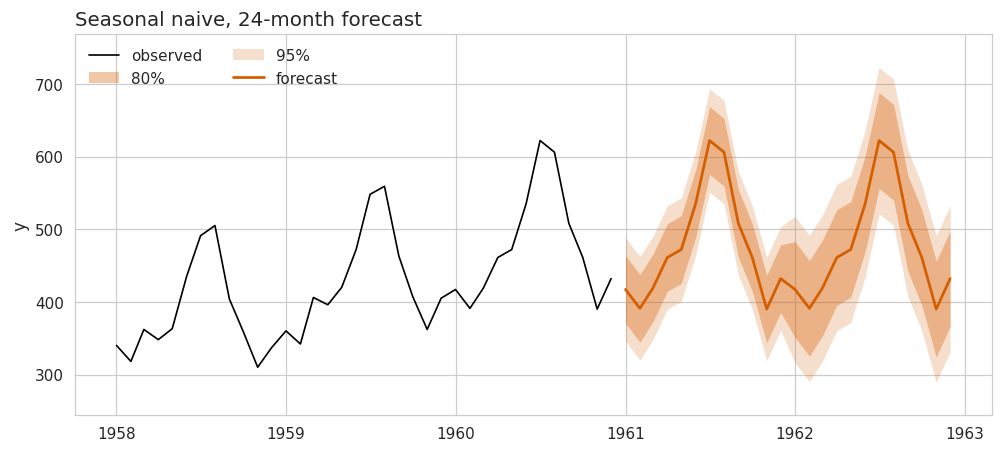

In [16]:
P.fan_chart(df, floor_fc.rename(columns={
            "SeasonalNaive": "mean",
            "SeasonalNaive-lo-20": "lo-20",
            "SeasonalNaive-lo-40": "lo-40",
            "SeasonalNaive-lo-60": "lo-60",
            "SeasonalNaive-lo-80": "lo-80",
            "SeasonalNaive-lo-95": "lo-95",
            "SeasonalNaive-hi-20": "hi-20",
            "SeasonalNaive-hi-40": "hi-40",
            "SeasonalNaive-hi-60": "hi-60",
            "SeasonalNaive-hi-80": "hi-80",
            "SeasonalNaive-hi-95": "hi-95",
            "ds": "ds"}),
            title="Seasonal naive, 24-month forecast",
            history_tail=36, levels=(80, 95))
plt.show()

**2.1 What is left on the table.** The floor's in-sample residuals are
``y_t - y_{t-12}`` over the series. Ljung-Box at 12 and 24 lags. If it is not
white noise, what structure is it, and which kind of model eats that
structure?

In [19]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid_floor = (
    df["y"] - df["y"].shift(SEASON_LENGTH)
).dropna()

lb_floor = acorr_ljungbox(
    resid_floor,
    lags=[12, 24],
    return_df=True
)

print(lb_floor)

       lb_stat     lb_pvalue
12  234.493675  2.319678e-43
24  275.036389  1.711303e-44


The Ljung-Box test indicates that the seasonal naive residuals still contain autocorrelation. Therefore, the seasonal naive model leaves systematic structure unexplained, suggesting that a model capturing both trend and seasonality may improve the forecast.

---
# 3. Your model: the framework

AutoGluon fits a zoo of models behind one call - every model in the zoo
below is a model you have met in this course. The install is large, so this
runs on Colab.

> Every cell in this section is **skip-guarded**: without `autogluon`
> installed it prints why and moves on, so the rest of the notebook still
> runs.

In [29]:
from statsforecast.models import AutoETS

ets_sf = StatsForecast(
    models=[
        AutoETS(
            season_length=SEASON_LENGTH
        )
    ],
    freq="MS",
    n_jobs=1
)

ets_fit = ets_sf.fit(df=df)

ets = ets_fit.fitted_[0, 0].model_

ets["method"]

'ETS(M,N,M)'

The selected AutoETS model is ETS(M,N,M). It uses multiplicative errors, no trend component, and multiplicative seasonality.

**3.1 The data conversion stays visible.** AutoGluon has its own
frame, its own column names, its own fit loop and its own leaderboard.
Writing it out by hand once is the point - the gap between two APIs doing
the same job is the thing to notice.

| | this course | AutoGluon |
|---|---|---|
| id column | `unique_id` | `item_id` |
| time column | `ds` | `timestamp` |
| value column | `y` | `target` (nameable) |
| frame | `pd.DataFrame` | `TimeSeriesDataFrame` |

In [39]:
!pip install -q autogluon.timeseries

In [40]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame

# Copy the original course dataframe
ag_df = df.copy()

# Rename columns for AutoGluon
ag_df = ag_df.rename(
    columns={
        "unique_id": "item_id",
        "ds": "timestamp",
        "y": "target"
    }
)

# Make sure timestamp is datetime
ag_df["timestamp"] = pd.to_datetime(ag_df["timestamp"])

# Convert to AutoGluon TimeSeriesDataFrame
ag_ts = TimeSeriesDataFrame.from_data_frame(
    ag_df,
    id_column="item_id",
    timestamp_column="timestamp"
)

ag_ts.head()

target
item_id                        timestamp         
Air passengers (Box & Jenkins) 1949-01-01   112.0
                               1949-02-01   118.0
                               1949-03-01   132.0
                               1949-04-01   129.0
                               1949-05-01   121.0

In [41]:
from autogluon.timeseries import TimeSeriesPredictor

predictor = TimeSeriesPredictor(
    target="target",
    prediction_length=12,
    eval_metric="MASE"
)

predictor.fit(train_data=ag_ts)

Beginning AutoGluon training...
AutoGluon will save models to '/content/proj/AutogluonModels/ag-20260907_171634'
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       10.99 GB / 12.67 GB (86.7%)
Disk Space Avail:   86.52 GB / 107.72 GB (80.3%)

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 12,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': '

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

...

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.7MB            

model.safetensors: downloading bytes:           |  0.00B            

	-0.4084       = Validation score (-MASE)
	2.11    s     = Training runtime
	0.12    s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. 
	-0.5043       = Validation score (-MASE)
	182.50  s     = Training runtime
	0.03    s     = Validation (prediction) runtime
Training timeseries model DeepAR. 
	-0.4165       = Validation score (-MASE)
	145.14  s     = Training runtime
	0.11    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. 
	Ensemble weights: {'DeepAR': 0.19, 'RecursiveTabular': 0.25, 'Toto2': 0.56}
	-0.3564       = Validation score (-MASE)
	0.96    s     = Training runtime
	0.35    s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'Chronos2', 'AutoETS', 'Toto2', 'TemporalFusionTransformer', 'DeepAR', 'WeightedEnsemble']
Total runtime: 362.01 s
Best model: WeightedEnsem

In [42]:
leaderboard = predictor.leaderboard()
leaderboard

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.356383,0.348583,0.958884,10
1,Toto2,-0.408376,0.115974,2.112428,7
2,DeepAR,-0.416510,0.106788,145.143682,9
3,Chronos2,-0.441565,0.714444,19.334819,5
4,RecursiveTabular,-0.467084,0.121253,0.910219,2
5,TemporalFusionTransformer,-0.504346,0.027969,182.504058,8
6,AutoETS,-1.169539,0.101265,0.015743,6
7,SeasonalNaive,-1.570881,0.011884,0.029064,1
8,DynamicOptimizedTheta,-1.570881,0.032316,0.018996,4
9,DirectTabular,-1.602008,0.085343,2.484850,3


AutoGluon evaluated multiple forecasting models using MASE. The WeightedEnsemble achieved the best validation performance with a score_val of -0.356383, corresponding to a MASE of approximately 0.356. Toto2 was the second-best model with a MASE of approximately 0.408, followed by DeepAR with approximately 0.417. Since AutoGluon flips the sign of MASE so that higher scores are better, the score closest to zero represents the best model.

**3.2 Read what it handed back.** What is the *sign* of `score_val`, and
what does the answer to "how many windows" mean for how much you should
trust this ranking? It decides what the next section does with this table.
And: does the shortlist agree with the shape you read in section 1?

---
# 4. The harness

The framework's ranking came from one internal split. One holdout is not a
ranking. So the shortlist goes through the rolling-origin harness: eight
origins, twelve months each, the whole distribution scored - and the floor
stays in the table.

In [43]:
sf_cv = StatsForecast(
    models=[
        SeasonalNaive(
            season_length=SEASON_LENGTH
        )
    ],
    freq="MS",
    n_jobs=1
)

cv = sf_cv.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

cv.head()

,unique_id,ds,cutoff,y,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80,SeasonalNaive-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,171.0,164.48674,157.518271,149.362895,138.052796,120.6116,177.51326,184.481729,192.637105,203.947204,221.3884
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,180.0,173.48674,166.518271,158.362895,147.052796,129.6116,186.51326,193.481729,201.637105,212.947204,230.3884
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.0,186.48674,179.518271,171.362895,160.052796,142.6116,199.51326,206.481729,214.637105,225.947204,243.3884
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,181.0,174.48674,167.518271,159.362895,148.052796,130.6116,187.51326,194.481729,202.637105,213.947204,231.3884
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,183.0,176.48674,169.518271,161.362895,150.052796,132.6116,189.51326,196.481729,204.637105,215.947204,233.3884


In [44]:
from statsforecast.models import AutoETS

MY_MODEL = AutoETS()
MY_NAME = "AutoETS"

mysf = StatsForecast(
    models=[MY_MODEL],
    freq="MS",
    n_jobs=1
)

mycv = mysf.cross_validation(
    df=df,
    h=H,
    step_size=H,
    n_windows=8,
    level=scoring.LEVELS
)

mycv.head()

,unique_id,ds,cutoff,y,AutoETS,AutoETS-lo-95,AutoETS-lo-80,AutoETS-lo-60,AutoETS-lo-40,AutoETS-lo-20,AutoETS-hi-20,AutoETS-hi-40,AutoETS-hi-60,AutoETS-hi-80,AutoETS-hi-95
0,Air passengers (Box & Jenkins),1953-01-01,1952-12-01,196.0,193.9978,153.089473,167.249282,176.431499,183.052524,188.709945,199.285656,204.943077,211.564101,220.746318,234.906128
1,Air passengers (Box & Jenkins),1953-02-01,1952-12-01,196.0,193.9978,135.980430,156.062281,169.084766,178.474893,186.498411,201.497189,209.520707,218.910835,231.933319,252.015170
2,Air passengers (Box & Jenkins),1953-03-01,1952-12-01,236.0,193.9978,122.736824,147.402752,163.397875,174.931484,184.786528,203.209072,213.064116,224.597725,240.592848,265.258777
3,Air passengers (Box & Jenkins),1953-04-01,1952-12-01,235.0,193.9978,111.474757,140.038883,158.561871,171.918249,183.330781,204.664820,216.077352,229.433730,247.956718,276.520843
4,Air passengers (Box & Jenkins),1953-05-01,1952-12-01,229.0,193.9978,101.466605,133.494904,154.264305,169.240505,182.037116,205.958484,218.755095,233.731295,254.500697,286.528996


In [50]:
# Score both models on the same 8 rolling-origin folds

floor_results = scoring.score_cv(
    cv,
    "SeasonalNaive",
    df,
    seasonality=SEASON_LENGTH
)

my_results = scoring.score_cv(
    mycv,
    MY_NAME,
    df,
    seasonality=SEASON_LENGTH
)

RESULTS = pd.DataFrame(
    [floor_results, my_results],
    index=["SeasonalNaive", MY_NAME]
)

RESULTS

,mase,rmsse,crps,coverage_80,mase_min,mase_max
SeasonalNaive,1.313310,1.245572,0.061603,0.510417,0.411584,1.958726
AutoETS,2.061432,2.389743,0.105503,0.812500,1.421879,3.196465




The rolling-origin harness moves the shortlist rather than confirming AutoETS as the better overall model. SeasonalNaive beats AutoETS on all three accuracy metrics: MASE (1.313 vs 2.061), RMSSE (1.246 vs 2.390), and scaled CRPS (0.062 vs 0.106). Therefore, the seasonal-naive floor remains stronger for point and distributional forecast accuracy.

AutoETS does, however, perform much better on interval coverage. Its 80% prediction interval covers 81.25% of the actual observations, which is very close to the nominal 80% level. This suggests that AutoETS's prediction band is reasonably calibrated. In contrast, SeasonalNaive achieves only 51.04% coverage, suggesting that its nominal 80% prediction band is too narrow.

The result is therefore a trade-off: SeasonalNaive has better point and distributional accuracy, while AutoETS provides much better-calibrated 80% prediction intervals.[link text](https://)

---
# 5. The report

The notebook is evidence; the report is the claim. Two to three pages, for a
manager who will not open the notebook:

- **The recommendation.** Which model you would ship, in one sentence, and
  the one number that earns it.
- **The intervals.** How wide, what they covered, and whether the band is
  honest. Coverage is the check a band cannot do alone.
- **The residuals.** What the floor - and your model - missed. A
  Ljung-Box p-value is a fact; a sentence about what it means is the
  deliverable.
- **One change.** A specific next step - data, driver, frequency, horizon -
  and what you expect it to do.

Rules: every number in the report comes out of this notebook; no number
that could not have come out of the harness counts; no leakage - a fold's
fit and its denominator use only data that fold was allowed to see.

**Optional, for extra credit.** The series is a total across origins, so a
driver is a modelling choice, not a lookup: pick a region and pull its
monthly mean temperature from a public weather archive (for example
Open-Meteo's historical API - free, no key), cache it next to the CSV, and
regress on it. That is dynamic regression - and the cross-validation
discipline still applies to the regression's residuals.